# **Dataset processing for Foreign Body Detection**



## 1. Load the dataset

In [1]:
# Import libraries
import os
import random
import pickle
import pandas as pd
import cv2
import imgaug as ia
import imageio
from imgaug import augmenters as iaa
import shutil
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import glob
import numpy as np
from PIL import Image, ImageOps
from sklearn.preprocessing import LabelEncoder
import albumentations as A
pd.options.mode.chained_assignment = None  # default='warn'

from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# Download the base datasets
GDRIVE_DATASET_PATH = "/content/gdrive/MyDrive/Datasets 📊/QuinoaInspector/Imagenes_227_RGB-20240423T174613Z-001.zip"
LOCAL_DATASET = "/content/dataset"

# Define which datasets is being generated
DATASET_VERSION = "AUGMENTED" # options: AUGMENTED, ROW

if os.path.exists(LOCAL_DATASET):
  shutil.rmtree(LOCAL_DATASET)
os.mkdir(LOCAL_DATASET)

!unzip "$GDRIVE_DATASET_PATH" -d "$LOCAL_DATASET"  > /dev/null

# Move all subfolders into /content/dataset
for folder in os.listdir(os.path.join(LOCAL_DATASET, "Imagenes_227_RGB")):
  base_path = os.path.join(LOCAL_DATASET,"Imagenes_227_RGB",folder)
  target_path = os.path.join(LOCAL_DATASET,folder)
  shutil.move(base_path, target_path)

shutil.rmtree(os.path.join(LOCAL_DATASET,"Imagenes_227_RGB"))

In [3]:
# Create a dataframe for the dataset
images = []
labels = []
for folder in os.listdir(LOCAL_DATASET):
  for image in glob.glob(os.path.join(LOCAL_DATASET,folder,"*.jpg")):
    images.append(image)
    labels.append(folder)

dataset = pd.DataFrame(list(zip(images, labels)),
               columns =['image', 'label'])

## 2. Exploratory Data Analysis

a-Good:1000 b-Dark:1000 b-Yellow:1000 c-Broken:1000 c-Covered:1000 c-Damaged:1000 c-Red:1000 c-Sproten:1000 c-Unriped:1000 d-Bidens:1000 d-Hordeum:1000 d-Larva:1000 d-Perigoneum:1000 d-Rat feces:1000 d-Stem:1000 e-Clod:1000 e-Stone:1000 

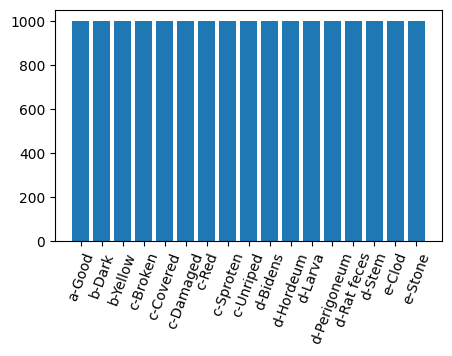

In [4]:
def show_label_frequency(dataset):
  label_frequency = dataset.groupby("label").size()
  plt.figure(figsize=(5,3))
  plt.bar(label_frequency.index, height=label_frequency)
  plt.xticks(rotation=70);
  for label, frequency in zip(label_frequency.index, label_frequency):
    print(label+":"+str(frequency), end=" ")
show_label_frequency(dataset)

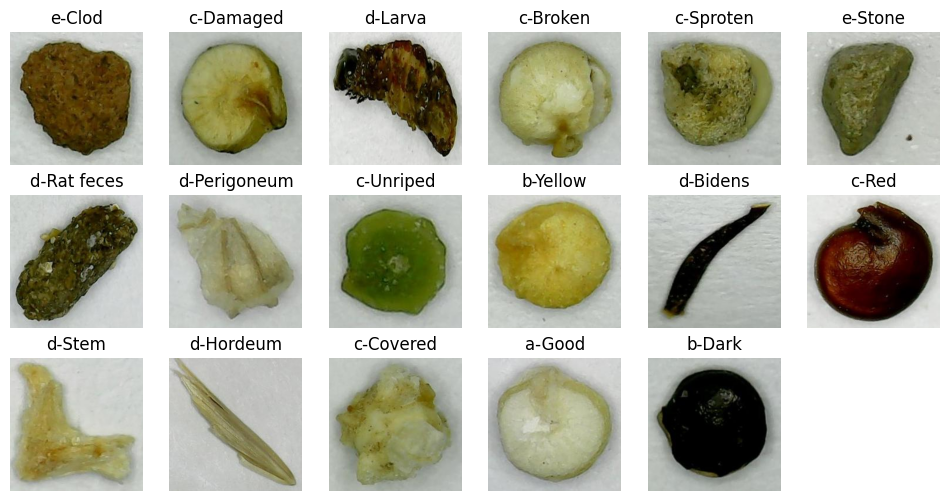

In [5]:
# Show a sample per category
def show_random_samples(dataset, rows, columns, replacement=False):
  selected_images = {}
  replacement_categories = {"a-Good":"white","b-Dark":"black","c-Red":"red",
                            "d-Larva":"larva","d-Rat feces":"rat feces",
                            "d-Stem":"stem","e-Clod":"clod","e-Stone":"stone"}
  for category in list(dataset["label"].unique()):
    num = random.randint(0, len(dataset)-1)

    while dataset.at[num,"label"] != category:
      num = random.randint(0, len(dataset)-1)
    selected_images[category] = dataset.at[num,"image"]


  fig = plt.figure(figsize=(12,6))
  for plot, category in zip(range(0,len(dataset["label"].unique())), list(dataset["label"].unique())):
    image = cv2.imread(selected_images[category])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax = fig.add_subplot(rows,columns,plot+1)
    ax.imshow(image)
    if replacement:
      ax.set_title(replacement_categories[category])
    else:
      ax.set_title(category)
    ax.axis('off')

show_random_samples(dataset, 3, 6, False)

## 3. Identify and remove duplicates

In [6]:
if DATASET_VERSION == "AUGMENTED":
  DUPLICATED_SAMPLES_BACKUP = "/content/gdrive/MyDrive/Datasets 📊/QuinoaInspector/repeated"

  def save_findings(similars, target_path):
    f = open(target_path, "w")

    for key, value in similars.items():
      similar_list = ""
      for v in value:
        similar_list +=(v[17:]+";")
      f.write(key[17:]+":"+similar_list+"\n")
    f.close()

  categories = list(dataset["label"].unique())
  similars_listing = []
  for category in categories:
    print("Processing",category)
    target_path = os.path.join(DUPLICATED_SAMPLES_BACKUP,category+".txt")
    if os.path.exists(target_path):
      continue

    df = dataset[dataset["label"]==category]
    similars_in_category = {}
    for idx, samplex in tqdm(df.iterrows(), total=len(df)):
      image_x_path = df.at[idx, "image"]
      similars_in_category[image_x_path] = []
      if image_x_path in similars_listing:
        continue
      imagex = Image.open(image_x_path)
      for idy, sampley in df.iterrows():
        if idy == idx:
          continue
        image_y_path = df.at[idy, "image"]
        imagey = Image.open(image_y_path)

        if np.array_equal(np.array(imagex),np.array(imagey)):
          similars_in_category[image_x_path].append(image_y_path)
          similars_listing.append(image_y_path)

      save_findings(similars_in_category, target_path)

Processing e-Clod
Processing c-Damaged
Processing d-Larva
Processing c-Broken
Processing c-Sproten
Processing e-Stone
Processing d-Rat feces
Processing d-Perigoneum
Processing c-Unriped
Processing b-Yellow
Processing d-Bidens
Processing c-Red
Processing d-Stem
Processing d-Hordeum
Processing c-Covered
Processing a-Good
Processing b-Dark


unique: 12587 74.04117647058824% repeated: 4413 25.958823529411763%
Original dataset length: 17000
New dataset length: 12587
a-Good:803 b-Dark:789 b-Yellow:759 c-Broken:730 c-Covered:678 c-Damaged:777 c-Red:759 c-Sproten:712 c-Unriped:738 d-Bidens:764 d-Hordeum:607 d-Larva:756 d-Perigoneum:757 d-Rat feces:713 d-Stem:761 e-Clod:729 e-Stone:755 

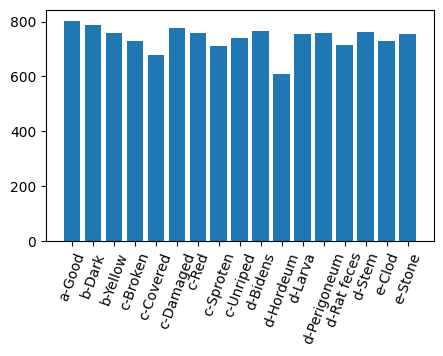

In [7]:
if DATASET_VERSION == "AUGMENTED":
  DUPLICATED_SAMPLES_BACKUP = "/content/gdrive/MyDrive/Datasets 📊/QuinoaInspector/repeated"

  unique_items = []
  for txt_file in os.listdir(DUPLICATED_SAMPLES_BACKUP):
    f = open(os.path.join(DUPLICATED_SAMPLES_BACKUP, txt_file), "r")
    lines = f.readlines()
    for line in lines:
      duplicates_list = line.split(":")[1]
      if len(duplicates_list) <= 1:
        unique_items.append(line[:-2])

  unique = len(unique_items)
  print("unique:", str(unique), str(unique*100/17000)+"%","repeated:", str(17000-unique), str((17000-unique)*100/17000)+"%")

  print("Original dataset length:",len(dataset))
  for idx, sample in dataset.iterrows():
    if sample["image"][17:] not in unique_items:
      dataset.drop(index=idx, inplace=True)
      os.remove(sample["image"])

  print("New dataset length:",len(dataset))
  dataset.reset_index(inplace=True, drop=True)
  show_label_frequency(dataset)

In [8]:
shutil.make_archive("stem", format='zip', root_dir="/content/dataset/d-Stem")
!cp stem.zip "/content/gdrive/MyDrive/Datasets 📊/QuinoaInspector/stem.zip"

## 4. Remove categories

In [ ]:
chosen_categories = [
                     #"a-Good", "c-Red", "b-Dark", # Good quality categories
                     "d-Larva", "d-Stem", "d-Rat feces", # Organic foreign bodies
                     "e-Clod", "e-Stone" # Inorganic foreign bodies
                    ]
temp_dataset = dataset[dataset['label'].isin(chosen_categories)]

for folder in glob.glob(LOCAL_DATASET+"/*/"):
  if folder.split("/")[-2] not in chosen_categories:
    shutil.rmtree(folder)

d-Larva:756 d-Rat feces:713 d-Stem:761 e-Clod:729 e-Stone:754 

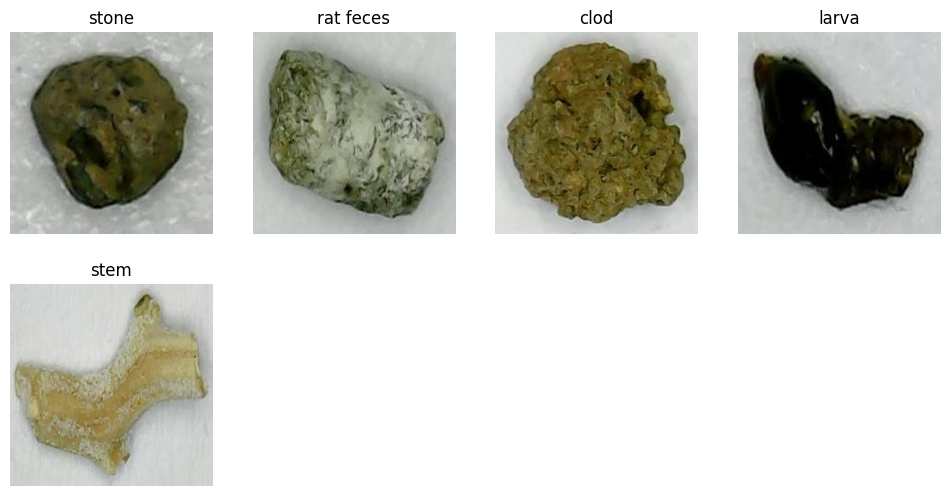

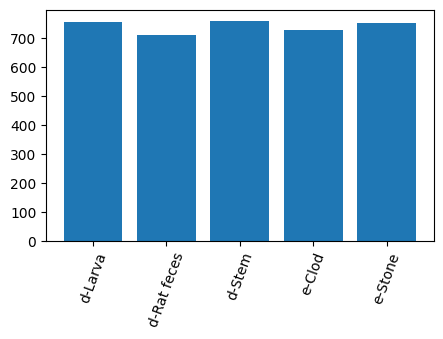

In [ ]:
# Remove poor sample with a small stem
if DATASET_VERSION == "AUGMENTED":
  os.remove(temp_dataset.at[1512,"image"])
  temp_dataset.drop(index=[1512], inplace=True)
else:
  os.remove(temp_dataset.at[2193,"image"])
  temp_dataset.drop(index=[2193, 7875], inplace=True)
temp_dataset.reset_index(inplace=True, drop=True)
show_random_samples(temp_dataset, 2, 4, True)
show_label_frequency(temp_dataset)

In [ ]:
# temp_group = temp_dataset.groupby("label")
# temp_group = temp_group.get_group("d-Stem")

# for idx, sample in temp_dataset.iterrows():
#   i = cv2.cvtColor(cv2.imread(temp_dataset.at[idx,"image"]), cv2.COLOR_BGR2RGB)
#   hsv_image = cv2.cvtColor(i, cv2.COLOR_RGB2HSV)
#   lower_hue = np.array([0,20,40])
#   upper_hue = np.array([90,255,255])
#   try:
#     mask = cv2.inRange(hsv_image, lower_hue, upper_hue)
#     kernel = cv2.getStructuringElement(cv2.MORPH_CROSS,(9,9))
#     closing = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
#     opening = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel, iterations=3)
#     analysis = cv2.connectedComponentsWithStats(opening, 4, cv2.CV_32S)
#     (component_labels, label_id_pixel, values, centroid) = analysis
#     xmin = values[1, cv2.CC_STAT_LEFT]
#     ymin = values[1, cv2.CC_STAT_TOP]
#     xmax = xmin + values[1, cv2.CC_STAT_WIDTH]
#     ymax = ymin + values[1, cv2.CC_STAT_HEIGHT]
#   except:
#     plt.imshow(i)
#     print(idx)
#     break

## 5. Augment dataset

In [ ]:
if DATASET_VERSION == "AUGMENTED":
  # Define the number of samples needed for each class
  number_samples = 1500

  d = temp_dataset.groupby(['label']).size().reset_index(name='size')
  aug_needed={}

  for i, j in d.iterrows():
    cls=j['label']
    cnt=j['size']
    if cnt > number_samples:
      aug_needed[cls] = 1 ## 1 means these images will go through augmenation once, hence keeping the same count for training.
    else:
      aug_needed[cls] = number_samples-cnt

  print(aug_needed)

{'d-Larva': 744, 'd-Rat feces': 787, 'd-Stem': 739, 'e-Clod': 771, 'e-Stone': 746}


In [ ]:
# This function applies data augmentation according to the necessary samples to balance a dataset
def image_aug(df, aug_images_path, image_prefix, augmentor, cls, needed_augmentations):
  # Create data frame which we're going to populate with augmented image info
  aug_df = pd.DataFrame(columns=df.columns)
  grouped = df.groupby('label')

  group_df = grouped.get_group(cls)
  group_df = group_df.reset_index()

  os.mkdir(os.path.join(aug_images_path, cls))
  count = 0
  new_images_paths = []
  new_labels = []
  while count < needed_augmentations:
    for idx, sample in group_df.iterrows():
      base_image_path = sample["image"]

      # Open the image
      image = imageio.v3.imread(base_image_path)

      # Apply augmentation on image and on the bounding boxes
      augmented_image = augmentor(image=image)['image']

      # Write augmented image to a file
      target_path = os.path.join(aug_images_path, cls, image_prefix+"0_"+base_image_path.split("/")[-1])
      c = 1
      while os.path.exists(target_path):
        target_path = os.path.join(aug_images_path, cls, image_prefix+str(c)+"_"+base_image_path.split("/")[-1])
        c += 1
      imageio.imwrite(target_path, augmented_image)
      # Concat all new augmented info into new data frame
      new_images_paths.append(target_path)
      new_labels.append(cls)
      count += 1

      if count >= needed_augmentations:
        break

  aug_df["image"] = new_images_paths
  aug_df["label"] = new_labels

  return aug_df

if DATASET_VERSION == "AUGMENTED":
  augmentor = A.Compose([A.OneOf([
      A.Sequential([A.HorizontalFlip(p=1),
                    A.VerticalFlip(p=1)]),
      A.Sequential([A.VerticalFlip(p=1)]),
      A.Sequential([A.HorizontalFlip(p=1)]),
  ], p=1)])

  AUGMENTED_DATASET = "/content/augmented_dataset"

  # Perform augmentation
  if os.path.exists(AUGMENTED_DATASET):
    shutil.rmtree(AUGMENTED_DATASET)
  os.mkdir(AUGMENTED_DATASET)
  augmented_images_df = pd.DataFrame(columns=temp_dataset.columns)

  for cls, aug_need in tqdm(aug_needed.items(), total=len(aug_needed)):
    print('Images augmented for category ', cls,':',aug_need)
    augmented_images_df = pd.concat(
        [augmented_images_df, image_aug(temp_dataset, AUGMENTED_DATASET, 'aug', augmentor, cls, aug_need)],
        ignore_index=True)
    augmented_images_df.reset_index(inplace=True, drop=True)

  print('Done')

  0%|          | 0/5 [00:00<?, ?it/s]

Images augmented for category  d-Larva : 744
Images augmented for category  d-Rat feces : 787
Images augmented for category  d-Stem : 739
Images augmented for category  e-Clod : 771
Images augmented for category  e-Stone : 746
Done


New dataset size: 7500
Existent files: 7500
d-Larva:1500 d-Rat feces:1500 d-Stem:1500 e-Clod:1500 e-Stone:1500 

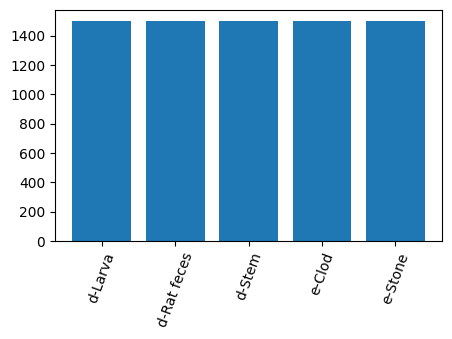

In [ ]:
if DATASET_VERSION == "AUGMENTED":
  copy_data = temp_dataset.copy()
  #Combine datasets
  for idx, sample in temp_dataset.iterrows():
    category = sample["image"].split("/")[-2]
    file_name = sample["image"].split("/")[-1]
    target_path = os.path.join(AUGMENTED_DATASET, category, file_name)
    shutil.copy(sample["image"],target_path)
    copy_data.at[idx, "image"] = target_path

  augmented_dataset = pd.concat([augmented_images_df, copy_data], ignore_index=True)
  # os.remove(augmented_dataset.at[4321,"image"])
  # augmented_dataset.drop(index=[4321], inplace=True)
  augmented_dataset.reset_index(inplace=True, drop=True)
  print("New dataset size:", len(augmented_dataset))
  print("Existent files:", len(glob.glob(AUGMENTED_DATASET+"/*/*.jpg")))
  show_label_frequency(augmented_dataset)

## 6. Create bounding boxes

In [ ]:
def extract_bounding_boxes(dataset, DATASET_VERSION):
  xmins = []
  xmaxs = []
  ymins = []
  ymaxs = []
  masks = []
  for idx, sample in tqdm(dataset.iterrows(), total=len(dataset)):
    # if idx != 7875:
    #   continue
    image = cv2.imread(sample["image"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_bbox = np.copy(image)
    blurred = cv2.GaussianBlur(image, (7, 7), 0)
    if sample["label"] in ["a-Good","d-Stem"]:
      # Obtain the base mask
      hsv_image = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
      lower_hue = np.array([0,20,40])
      upper_hue = np.array([90,255,255])
      mask = cv2.inRange(hsv_image, lower_hue, upper_hue)
      kernel = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
      mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=3)
      mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
      mask = cv2.morphologyEx(mask, cv2.MORPH_ERODE, kernel, iterations=3)

    elif sample["label"] == "d-Larva":
      hsv_image = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
      lower_hue = np.array([0,20,0])
      upper_hue = np.array([90,255,255])
      mask = cv2.inRange(hsv_image, lower_hue, upper_hue)
      kernel = cv2.getStructuringElement(cv2.MORPH_CROSS,(5,5))
      mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
      mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=5)
      kernel = np.ones((3,3))
      mask = cv2.morphologyEx(mask, cv2.MORPH_ERODE, kernel, iterations=1)
      copy_mask = np.copy(mask)

    else:
      gray_image = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
      ret, mask = cv2.threshold(gray_image,0,255,cv2.THRESH_OTSU)
      mask = 255 - mask
      kernel = cv2.getStructuringElement(cv2.MORPH_CROSS,(9,9))
      mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
      mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=3)

    # Find the contourn of the element
    contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros(mask.shape, dtype=np.uint8)
    cv2.drawContours(mask, contours, 0, (255,255,255),-1)
    target_mask_path = sample["image"].replace("jpg","png")
    cv2.imwrite(target_mask_path, mask)
    masks.append(target_mask_path)

    analysis = cv2.connectedComponentsWithStats(mask, 4, cv2.CV_32S)
    (component_labels, label_id_pixel, values, centroid) = analysis
    xmin = values[1, cv2.CC_STAT_LEFT]
    ymin = values[1, cv2.CC_STAT_TOP]
    xmax = xmin + values[1, cv2.CC_STAT_WIDTH]
    ymax = ymin + values[1, cv2.CC_STAT_HEIGHT]

    # color = (0, 200, 255)
    # image_bbox = cv2.rectangle(image_bbox, (xmin, ymin), (xmax,ymax), color, thickness = 2)

    # f, axarr = plt.subplots(1,3, figsize=(12,6))
    # axarr[0].imshow(image)
    # axarr[1].imshow(image)
    # axarr[1].imshow(copy_mask,cmap="gray",alpha=0.5)
    # axarr[2].imshow(image_bbox)

    xmins.append(xmin)
    xmaxs.append(xmax)
    ymins.append(ymin)
    ymaxs.append(ymax)

  dataset["xmin"] = xmins
  dataset["xmax"] = xmaxs
  dataset["ymin"] = ymins
  dataset["ymax"] = ymaxs
  dataset["mask"] = masks

  # Transform categories into numbers
  le = LabelEncoder()
  le.fit(dataset["label"])
  dataset["num_label"] = le.transform(dataset["label"])
  return dataset

if DATASET_VERSION == "AUGMENTED":
  augmented_dataset = extract_bounding_boxes(augmented_dataset,DATASET_VERSION)
else:
  temp_dataset = extract_bounding_boxes(temp_dataset, DATASET_VERSION)

  0%|          | 0/7500 [00:00<?, ?it/s]

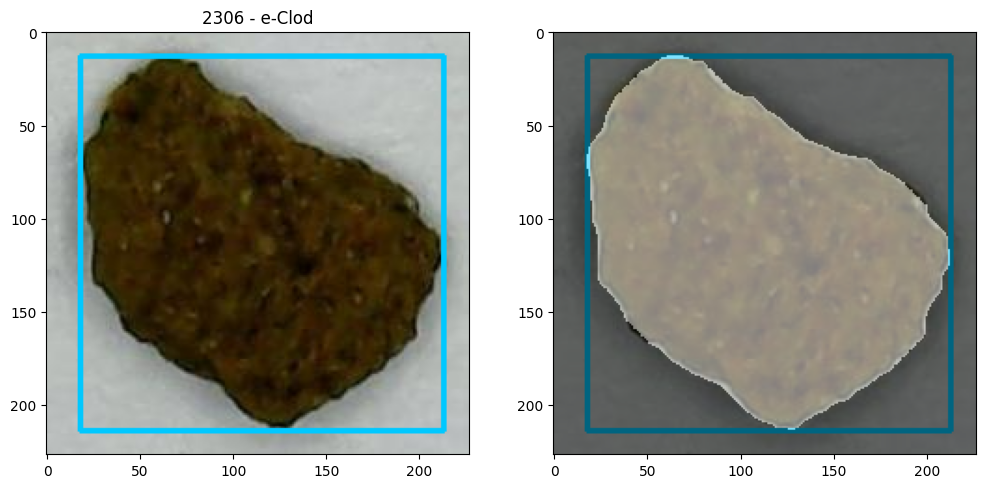

In [ ]:
def show_random_sample_bbox(dataset):
  num = random.randint(0,len(temp_dataset)-1)
  color = (0, 200, 255)
  image = cv2.imread(dataset.at[num,"image"])
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  image = cv2.rectangle(image, (dataset.at[num,"xmin"], dataset.at[num,"ymin"]), (dataset.at[num,"xmax"],dataset.at[num,"ymax"]), color, thickness = 2)

  f, axarr = plt.subplots(1,2, figsize=(12,6))
  axarr[0].set_title(str(num)+" - "+dataset.at[num,"label"])
  axarr[0].imshow(image);
  mask = cv2.imread(dataset.at[num,"mask"])
  axarr[1].imshow(image)
  axarr[1].imshow(mask,alpha=0.5);

if DATASET_VERSION == "AUGMENTED":
  show_random_sample_bbox(augmented_dataset)
else:
  show_random_sample_bbox(temp_dataset)

## 7. Create new images with multiple instances

  0%|          | 0/833 [00:00<?, ?it/s]

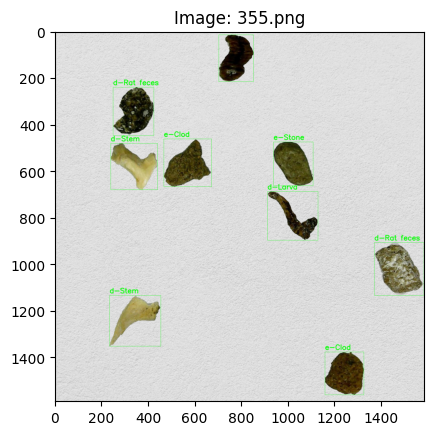

In [ ]:
# Create a list with the dataset indexes, such that
# each sample appears in the new dataset of grids once
def extract_sorted_list(dataset):
  unique_categories = dataset["label"].unique()

  groups = dataset.groupby("label")

  indexes = []
  for category in unique_categories:
    group = groups.get_group(category)
    indexes.append(list(group.index.values))

  sorted_list = []
  for x in list(map(list, zip(*indexes))):
    for y in x:
      sorted_list.append(y)

  return sorted_list

# Show n samples with TXT annotations
def show_samples_txt(dataset, classes, number):

  images = {}
  for i in range(number):
    index = random.randint(0,len(dataset)-1)
    image = cv2.imread(os.path.join(NEW_DATASET_PATH,dataset.at[index,"image"]))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width, _ = image.shape

    with open(os.path.join(NEW_DATASET_PATH,dataset.at[index,"txt"])) as txt:
      for line in txt.readlines():
        id = line.split(" ")[0]
        if len(id) > 0:
          id = int(id)
          label = classes[id]
          x=float(line.split(" ")[1])
          y=float(line.split(" ")[2])
          w=float(line.split(" ")[3])
          h=float(line.split(" ")[4])

          # Convert Yolo format to rectangular coordinates
          l = int((x - w / 2) * width)
          r = int((x + w / 2) * width)
          t = int((y - h / 2) * height)
          b = int((y + h / 2) * height)

          if l < 0:
            l = 0
          if r > width - 1:
            r = width - 1
          if t < 0:
            t = 0
          if b > height - 1:
            b = height - 1

          font = cv2.FONT_HERSHEY_SIMPLEX
          # Put text
          cv2.putText(image, label,(l,t-10),font,1,(0,255,0),2,cv2.LINE_AA)
          # Draw bounding box
          cv2.rectangle(image, (l, t), (r, b), (0,255,0), 1)

    plt.imshow(image)
    plt.title('Image: '+dataset.at[index,"image"].split("/")[3])

def convert_values(xmin, ymin, xmax, ymax, width, height):
  dw = 1./width
  dh = 1./height
  x = (xmin + xmax)/2.0
  y = (ymin + ymax)/2.0
  w = xmax - xmin
  h = ymax - ymin
  x_center = x*dw
  y_center = y*dh
  width = w*dw
  height = h*dh

  return x_center, y_center, width, height

def generate_new_dataset(dataset, NEW_DATASET_PATH, DATASET_VERSION, sorted_list):
  # Load the entire background. Create the base tile.
  entire_background_file_name = "background4.png"
  shutil.copy("/content/gdrive/MyDrive/Datasets 📊/QuinoaInspector/"+entire_background_file_name, "/content/")
  complete_background = cv2.cvtColor(cv2.imread(entire_background_file_name), cv2.COLOR_BGR2RGB)
  background = np.zeros((227,227), dtype=np.uint8)
  tile_size = background.shape[0] # 227

  # Start generating samples
  id = 0
  total_new_samples = len(dataset)//9
  new_images = []
  new_labels = []
  for instance in tqdm(range(0,total_new_samples), total=total_new_samples):
    entire_background = np.copy(complete_background)
    entire_background = entire_background -20
    # Select random tiles to place the samples
    selected_tiles = []

    while len(selected_tiles) < 9:
      x = random.randint(1,7)
      y = random.randint(1,7)
      if (x,y) not in selected_tiles:
        selected_tiles.append((x,y))

    # Create the entire base images (image, mask)
    base = np.zeros((tile_size*7, tile_size*7, 3), dtype=np.uint8)
    base_mask = np.zeros((tile_size*7, tile_size*7), dtype=np.uint8)

    records = []
    for i in range(1,8):
      for j in range(1,8):
        new_x_min = (i-1)*tile_size
        new_x_max = new_x_min+tile_size
        new_y_min = (j-1)*tile_size
        new_y_max = new_y_min+tile_size

        if (i,j) in selected_tiles:
          num = sorted_list.pop(0)
          image = cv2.imread(dataset.at[num,"image"])
          image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
          mask = cv2.imread(dataset.at[num,"mask"],0)
          image[mask == 0] = 0
          new_sub_mask = mask
          new_block = image
          x_center, y_center, width, height = convert_values(new_y_min+dataset.at[num,"xmin"],
                                                          new_x_min+dataset.at[num,"ymin"],
                                                          new_y_min+dataset.at[num,"xmax"],
                                                          new_x_min+dataset.at[num,"ymax"],
                                                            base.shape[0],base.shape[1])
          records.append(str(dataset.at[num,"num_label"])+" "+str(x_center)+" "+str(y_center)+" "+str(width)+" "+str(height)+ "\n")
        else:
          new_block = np.zeros((227,227,3), dtype=np.uint8)
          new_sub_mask = background

        base[new_x_min:new_x_max,new_y_min:new_y_max, :] = new_block
        base_mask[new_x_min:new_x_max,new_y_min:new_y_max] = new_sub_mask

    entire_background[base_mask!=0] = [0,0,0]
    base[base_mask==0] = [0,0,0]
    base = base + entire_background

    # Define the path name
    target_image_path = os.path.join(NEW_DATASET_PATH,str(id)+".png")
    target_txt_path = target_image_path.replace("png","txt")
    new_images.append(target_image_path)
    new_labels.append(target_txt_path)

    cv2.imwrite(target_image_path, cv2.cvtColor(base, cv2.COLOR_BGR2RGB))
    f = open(target_txt_path, "a")
    f.writelines(records)
    f.close()
    id += 1

  new_dataset = pd.DataFrame(columns=['image','txt'])
  new_dataset["image"] = new_images
  new_dataset["txt"] = new_labels

  return new_dataset

NEW_DATASET_PATH = "/content/new_dataset"

if os.path.exists(NEW_DATASET_PATH):
  shutil.rmtree(NEW_DATASET_PATH)
os.mkdir(NEW_DATASET_PATH)

if DATASET_VERSION == "AUGMENTED":
  sorted_list = extract_sorted_list(augmented_dataset)
  new_dataset = generate_new_dataset(augmented_dataset, NEW_DATASET_PATH, DATASET_VERSION, sorted_list)
else:
  sorted_list = extract_sorted_list(temp_dataset)
  new_dataset = generate_new_dataset(temp_dataset, NEW_DATASET_PATH, DATASET_VERSION, sorted_list)

show_samples_txt(new_dataset,
                {
                    # 0:"a-Good",1:"b-Dark",2:"c-Red", # Quinoa variants
                    # 3:"d-Larva",4:"d-Rat feces",5:"d-Stem",6:"e-Clod",7:"e-Stone" # Anomalies
                    0:"d-Larva",1:"d-Rat feces",2:"d-Stem",3:"e-Clod",4:"e-Stone" # Anomalies
                },
                 number=1)

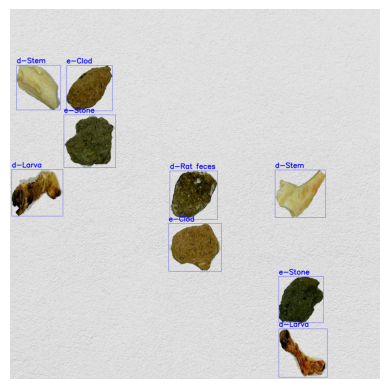

In [ ]:
# Show n samples with TXT annotations
def show_samples_txt2(dataset, classes, number):

  images = {}
  for i in range(number):
    index = random.randint(0,len(dataset)-1)
    image = cv2.imread(os.path.join(NEW_DATASET_PATH,dataset.at[index,"image"]))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width, _ = image.shape

    with open(os.path.join(NEW_DATASET_PATH,dataset.at[index,"txt"])) as txt:
      for line in txt.readlines():
        id = line.split(" ")[0]
        if len(id) > 0:
          id = int(id)
          label = classes[id]
          x=float(line.split(" ")[1])
          y=float(line.split(" ")[2])
          w=float(line.split(" ")[3])
          h=float(line.split(" ")[4])

          # Convert Yolo format to rectangular coordinates
          l = int((x - w / 2) * width)
          r = int((x + w / 2) * width)
          t = int((y - h / 2) * height)
          b = int((y + h / 2) * height)

          if l < 0:
            l = 0
          if r > width - 1:
            r = width - 1
          if t < 0:
            t = 0
          if b > height - 1:
            b = height - 1

          font = cv2.FONT_HERSHEY_SIMPLEX
          # Put text
          cv2.putText(image, label,(l,t-10),font,1,(0,0,255),2,cv2.LINE_AA)
          # Draw bounding box
          cv2.rectangle(image, (l, t), (r, b), (0,0,255), 1)

    plt.imshow(image)
    # plt.title('Image: '+dataset.at[index,"image"].split("/")[3])
    plt.axis('off')

show_samples_txt2(new_dataset,
                {                    # 0:"a-Good",1:"b-Dark",2:"c-Red", # Quinoa variants
                    # 3:"d-Larva",4:"d-Rat feces",5:"d-Stem",6:"e-Clod",7:"e-Stone" # Anomalies
                    0:"d-Larva",1:"d-Rat feces",2:"d-Stem",3:"e-Clod",4:"e-Stone" # Anomalies
                                     },
                 number=1)

## 8. Export dataset

In [ ]:
%cd /content/

classes = {0:"a-Good",1:"b-Dark",2:"c-Red",3:"d-Larva",4:"d-Rat feces",5:"d-Stem",6:"e-Clod",7:"e-Stone" }
pickle.dump(classes, open("new_dataset/classes.pkl", 'wb'))
new_dataset.to_csv('new_dataset/dataset.csv', index = True, header=True)
if DATASET_VERSION == "AUGMENTED":
  shutil.make_archive("augmented_dataset_2", format='zip', root_dir="/content/new_dataset")
  !cp augmented_dataset.zip "/content/gdrive/MyDrive/Datasets 📊/QuinoaInspector/"
else:
  shutil.make_archive("row_dataset", format='zip', root_dir="/content/new_dataset")
  !cp row_dataset.zip "/content/gdrive/MyDrive/Datasets 📊/QuinoaInspector/"

/content
cp: cannot stat 'augmented_dataset.zip': No such file or directory


In [ ]:
!cp augmented_dataset_2.zip "/content/gdrive/MyDrive/Datasets 📊/QuinoaInspector/"